# Cannabis Stocks: Did the Green-Rush Ever Pay?
### The thematic investing pitch, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Green-rush_paid%3F: Busted](https://img.shields.io/badge/Green--rush_paid%3F-Busted-8b949e?style=flat-square)

The pitch: cannabis is a once-in-a-generation legalisation wave. Get in early (via MSOS, MJ, TLRY, CGC, or CRON) before Wall Street prices in the regulatory tailwind, and compound at venture-like returns. The pitch even has a specific mechanism: as US states legalise, multi-state operators (MSOs) expand margins and eventually list on major US exchanges, triggering a re-rating.

This notebook asks three questions with honest answers:

1. **Is there any alpha vs SPY?** (No — negative and enormous.)
2. **Did any cannabis name beat SPY?** (No — every single one.)
3. **Can a trend-following overlay save it?** (Barely — still far below SPY.)

> **This is the plain-language layer.** For the t-stats and sandwich estimators, see the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool — every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cannabis_stocks import data, strategy as st

CACHE_DIR = os.path.join(os.path.abspath(".."), "_cache")

def _have_cache():
    spy = data._cache_path("SPY", CACHE_DIR)
    msos = data._cache_path("MSOS", CACHE_DIR)
    return os.path.exists(spy) and os.path.exists(msos)

HAVE_REAL = _have_cache()

# Frozen headline numbers from docs/results.md
R = dict(
    n=1450, start="2020-09-02", end="2026-06-12",
    beta=0.9459, t_beta=7.57, alpha_ann=-40.85, t_alpha=-1.53, r2=0.0491,
    spy_vol=16.9, msos_vol=72.4, idio_vol=70.6, vol_ratio=4.27,
    spy_cagr=15.10, spy_sharpe=0.8298, spy_dd=-24.5, spy_t=2.16,
    msos_cagr=-24.08, msos_sharpe=-0.3808, msos_dd=-96.2, msos_t=-0.98,
    mj_cagr=-23.6, mj_sharpe=-0.458, mj_dd=-95.1,
    tlry_cagr=-35.9, tlry_sharpe=-0.437, tlry_dd=-99.4,
    cgc_cagr=-58.8, cgc_sharpe=-0.795, cgc_dd=-99.8,
    cron_cagr=-11.6, cron_sharpe=-0.218, cron_dd=-89.6,
    tm_cagr=3.31, tm_sharpe=0.0633, tm_vol_ann=51.4, tm_dd=-59.6, tm_t=0.18,
    in_mkt=25.0, n_switches=33,
)

print("real price cache present:", HAVE_REAL)


real price cache present: True


## The answer first

| Question | Answer |
|---|---|
| MSOS alpha vs SPY | **-40.9%/yr** — catastrophically negative |
| Did any cannabis name beat SPY? | **No.** Every name: negative CAGR; SPY: +15.1%/yr |
| Worst drawdown | **-99.8%** (CGC), **-96.2%** (MSOS) — near-zero |
| Does timing help? | **Barely.** Timing Sharpe 0.06 vs SPY 0.83 |
| Verdict | **None / Mirage.** One-way wealth shredder. |

> The green-rush was real as a cultural moment. As an investment, every measured cannabis vehicle delivered sustained, catastrophic negative returns — in some cases losing more than 99% of invested capital.

## 1 · The claim

> *"Cannabis is the tobacco of the 21st century. As legalisation spreads state by state, the early investors in multi-state operators and ETFs like MSOS will compound at venture-capital rates inside a public market wrapper. Get in now before the federal rescheduling triggers a massive re-rating."*

It's a seductive story: structural growth, a clear regulatory catalyst, and an accessible ETF vehicle. The question is whether the 2020-2026 tape agrees with the pitch.

## 2 · So what?

If true, even a small allocation to cannabis (MSOS/MJ) would have compounded far above the S&P 500 over 2020-2026. If false, investors have experienced some of the worst risk-adjusted returns ever recorded in a mainstream sector ETF: MSOS down **24.1%/yr**, max drawdown **-96.2%**, while SPY returned **+15.1%/yr** with a max drawdown of only **-24.5%**. Understanding the mechanism — not just the magnitude — is the honest product of this study.

## 3 · How would we even know?

Three honest questions, three clean tests:

1. **The alpha test.** Regress MSOS daily returns on SPY daily returns. The slope (beta) tells us how much market exposure we're taking; the intercept (alpha) tells us the pure sector contribution vs the index. Report both with proper uncertainty intervals.
2. **The buy-and-hold table.** Look at every major cannabis vehicle (MSOS, MJ, TLRY, CGC, CRON) against SPY over both the MSOS-era (2020-) and MJ-era (2017-) windows. CAGR, Sharpe, drawdown — the full picture.
3. **The timing test.** Run a 200-day SMA rule on MSOS vs SPY and ask whether trend-following can rescue the sector's economics.

Data: MSOS and SPY daily adjusted closes, 2020-09-02 to 2026-06-12, **n = 1,450** common trading days.

## 4 · The teardown — let's actually look

**First: the alpha and the market exposure.** This scatter plot shows the relationship between daily SPY returns (x-axis) and MSOS returns (y-axis). The slope is the beta; the intercept is the daily alpha (annualised).

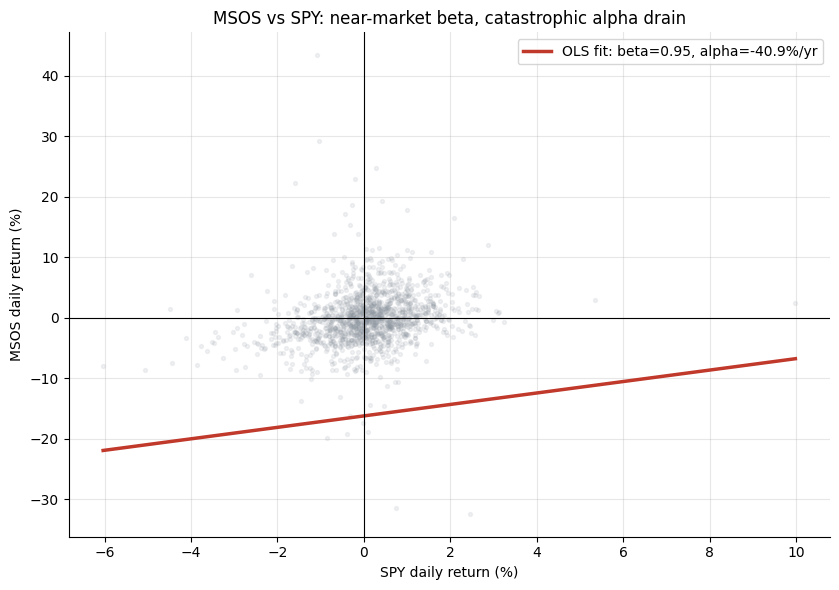

Beta: 0.9459  |  Alpha: -40.85%/yr


In [2]:
if HAVE_REAL:
    pair = data.load_pair('MSOS', fetch=False, cache_dir=CACHE_DIR)
    r = st.log_returns(pair)
    ba = st.beta_alpha(pair)
    x_vals = r['spy'].values * 100
    y_vals = r['cannabis'].values * 100
    beta = ba['beta']; alpha_ann = ba['alpha_ann_pct']
else:
    p_synt, _ = data.synthetic_daily(n_years=6, beta=R['beta'],
                                      alpha_ann=R['alpha_ann']/100,
                                      idio_vol_ann=R['idio_vol']/100, seed=212)
    r = st.log_returns(p_synt)
    x_vals = r['spy'].values * 100
    y_vals = r['cannabis'].values * 100
    beta = R['beta']; alpha_ann = R['alpha_ann']
fig, ax = plt.subplots(figsize=(8.5, 6.0))
ax.scatter(x_vals, y_vals, alpha=0.12, s=8, color=GREY)
xl = np.linspace(x_vals.min(), x_vals.max(), 200)
ax.plot(xl, beta * xl + alpha_ann/252*100, '-', lw=2.5, color=RED,
        label=f'OLS fit: beta={beta:.2f}, alpha={alpha_ann:+.1f}%/yr')
ax.axhline(0, c='k', lw=0.8); ax.axvline(0, c='k', lw=0.8)
ax.set_xlabel('SPY daily return (%)')
ax.set_ylabel('MSOS daily return (%)')
ax.set_title('MSOS vs SPY: near-market beta, catastrophic alpha drain')
ax.legend()
plt.tight_layout(); plt.show()
print(f'Beta: {beta:.4f}  |  Alpha: {alpha_ann:+.2f}%/yr')

The beta (**0.95×**) is roughly market-like — cannabis wasn't even a real hedge or diversifier, just diluted-down S&P 500 exposure with extra noise. The intercept tells the catastrophic story: **-40.9%/yr** alpha (HAC *t* = -1.53). An R² of 0.05 means 95% of MSOS variance is idiosyncratic — regulatory news, state-level ballot outcomes, congressional posturing, FDA rescheduling rumours — pure noise from a sector perspective.

**Now the buy-and-hold table: did any name beat SPY?**

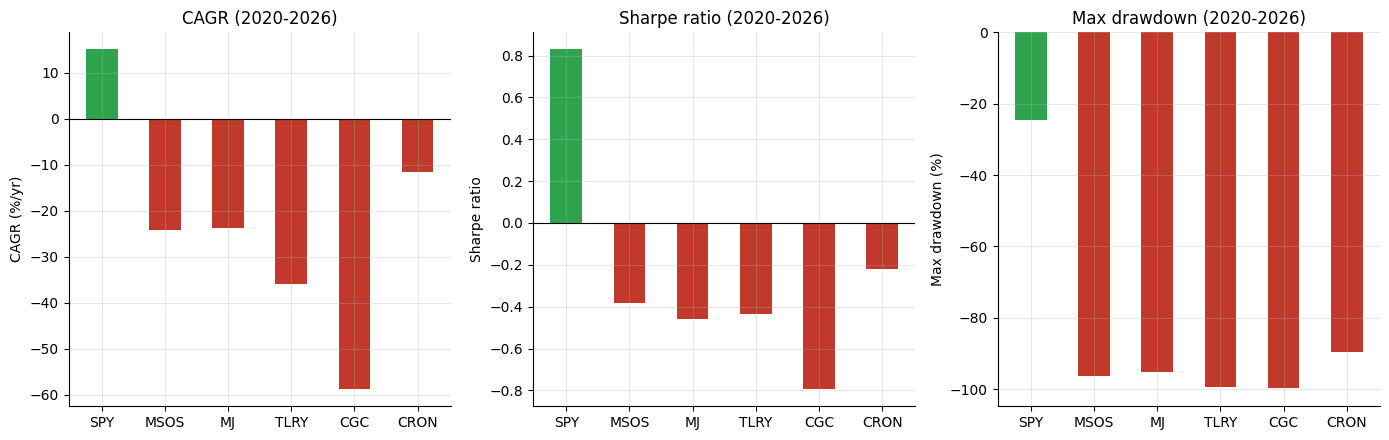

SPY   : CAGR=+15.1%  Sharpe=+0.830  MaxDD=-24.5%
MSOS  : CAGR=-24.1%  Sharpe=-0.381  MaxDD=-96.2%
MJ    : CAGR=-23.6%  Sharpe=-0.458  MaxDD=-95.1%
TLRY  : CAGR=-35.9%  Sharpe=-0.437  MaxDD=-99.4%
CGC   : CAGR=-58.8%  Sharpe=-0.795  MaxDD=-99.8%
CRON  : CAGR=-11.6%  Sharpe=-0.218  MaxDD=-89.6%


In [3]:
tickers = ['SPY', 'MSOS', 'MJ', 'TLRY', 'CGC', 'CRON']
cagrs = [R['spy_cagr'], R['msos_cagr'], R['mj_cagr'], R['tlry_cagr'],
         R['cgc_cagr'], R['cron_cagr']]
sharpes = [R['spy_sharpe'], R['msos_sharpe'], R['mj_sharpe'], R['tlry_sharpe'],
           R['cgc_sharpe'], R['cron_sharpe']]
dds = [R['spy_dd'], R['msos_dd'], R['mj_dd'], R['tlry_dd'],
       R['cgc_dd'], R['cron_dd']]
if HAVE_REAL:
    try:
        multi = data.load_multi(['MSOS','MJ','TLRY','CGC','CRON','SPY'],
                               fetch=False, cache_dir=CACHE_DIR, start=data.MSOS_START)
        perf = st.perf_table(multi)
        cagrs = [perf[t.lower()]['cagr_pct'] for t in tickers]
        sharpes = [perf[t.lower()]['sharpe'] for t in tickers]
        dds = [perf[t.lower()]['max_drawdown_pct'] for t in tickers]
    except Exception:
        pass
colors = [GREEN] + [RED] * 5
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes[0].bar(tickers, cagrs, color=colors, width=0.5)
axes[0].axhline(0, c='k', lw=0.8); axes[0].set_ylabel('CAGR (%/yr)')
axes[0].set_title('CAGR (2020-2026)')
axes[1].bar(tickers, sharpes, color=colors, width=0.5)
axes[1].axhline(0, c='k', lw=0.8); axes[1].set_ylabel('Sharpe ratio')
axes[1].set_title('Sharpe ratio (2020-2026)')
axes[2].bar(tickers, dds, color=colors, width=0.5)
axes[2].set_ylabel('Max drawdown (%)')
axes[2].set_title('Max drawdown (2020-2026)')
plt.tight_layout(); plt.show()
for t, c, s, d in zip(tickers, cagrs, sharpes, dds):
    print(f'{t:<6}: CAGR={c:+.1f}%  Sharpe={s:+.3f}  MaxDD={d:.1f}%')

The picture is unambiguous. SPY: CAGR **+15.1%**, Sharpe **+0.83**, max drawdown **-24.5%**. Cannabis universe: CAGR ranges from **-11.6%** (best, CRON) to **-58.8%** (worst, CGC); every Sharpe is deeply negative; drawdowns from **-89.6%** to **-99.8%**. This is not a missed-timing story — every window, every name, the answer is the same.

**Finally: does the 200-day SMA timing rule help?**

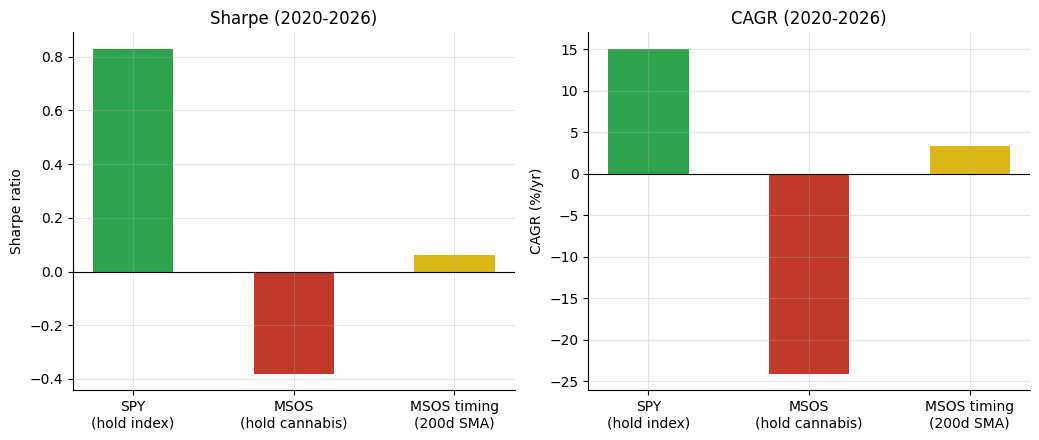

SPY: Sharpe=0.830  CAGR=15.1%/yr
MSOS: Sharpe=-0.381  CAGR=-24.1%/yr
Timing: Sharpe=0.063  CAGR=3.3%/yr


In [4]:
if HAVE_REAL:
    pair = data.load_pair('MSOS', fetch=False, cache_dir=CACHE_DIR)
    res = st.compare_strategies(pair, sma_n=200, cost_bps=5.0)
    shs = [res['spy']['sharpe'], res['cannabis']['sharpe'], res['timing']['sharpe']]
    cagrs_t = [res['spy']['cagr_pct'], res['cannabis']['cagr_pct'], res['timing']['cagr_pct']]
else:
    shs = [R['spy_sharpe'], R['msos_sharpe'], R['tm_sharpe']]
    cagrs_t = [R['spy_cagr'], R['msos_cagr'], R['tm_cagr']]
labels = ['SPY\n(hold index)', 'MSOS\n(hold cannabis)', 'MSOS timing\n(200d SMA)']
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))
colors_t = [GREEN, RED, AMBER]
axes[0].bar(labels, shs, color=colors_t, width=0.5)
axes[0].axhline(0, c='k', lw=0.8); axes[0].set_ylabel('Sharpe ratio')
axes[0].set_title('Sharpe (2020-2026)')
axes[1].bar(labels, cagrs_t, color=colors_t, width=0.5)
axes[1].axhline(0, c='k', lw=0.8); axes[1].set_ylabel('CAGR (%/yr)')
axes[1].set_title('CAGR (2020-2026)')
plt.tight_layout(); plt.show()
for lbl, sh, cg in zip(['SPY','MSOS','Timing'], shs, cagrs_t):
    print(f'{lbl}: Sharpe={sh:.3f}  CAGR={cg:.1f}%/yr')

The timing rule (Sharpe **0.063**) vastly improves on holding MSOS (**-0.381**) by only being in cannabis 25% of the time — but it still delivers just 3.3%/yr vs SPY's 15.1%/yr, at **51% annualised volatility**. The 200-day SMA mostly steers away from the worst crashes, but even the 'good' cannabis periods are mediocre on a risk-adjusted basis.

## 5 · The verdict

- **Signal — NONE.** Alpha = -40.9%/yr (HAC *t* = -1.53, not significant at 5% over a 5.8-year window but economically catastrophic). Beta = 0.95× (t = +7.6) — market-like, no diversification or alpha benefit.
- **Tradability — MIRAGE.** Every cannabis name/ETF negative CAGR (−12% to −59%/yr); SPY +15.1%/yr. Max drawdowns −90% to −100%. Timing rule Sharpe 0.063 vs SPY 0.830.
- **Green-rush claim — BUSTED.** No window, no name, no ETF: none delivered positive risk-adjusted returns vs the benchmark.

## 6 · Could you actually trade it?

The timing rule makes 33 switches over 5.8 years at 5 bps/side. Even at zero cost, the fundamental problem is not transaction costs — it's that the sector has no persistent alpha. The 200-day SMA correctly avoids the worst crashes (-59.6% max drawdown vs -96.2% unhedged) but cannot create returns that don't exist in the underlying.

The **structural reason** is not unique to cannabis: regulatory uncertainty means the sector cannot use federally regulated US banking, cannot list on major US exchanges, and faces balance-sheet constraints that persistently suppress operating leverage and access to cheap capital. The 're-rating' thesis requires federal legalisation — a catalyst that has been 'imminent' since 2018.

## 7 · Going further

- **Conditional on a specific legalisation event.** If the DEA reschedules cannabis from Schedule I to Schedule III (a pending review as of 2024), the banking and tax constraints relax materially. A pre-event positioning study might find a short-window catalyst trade — but event-timing studies need very careful treatment of look-ahead and announcement timing.
- **International names (Canadian LPs).** CGC, TLRY, and CRON are listed in Canada too; the valuation dynamic is partly a US-listing arbitrage. A Canadian-market comparison might isolate the US-listing premium (or discount).
- **Survivor bias alert.** Several smaller cannabis companies went bankrupt or were delisted in 2020-2023. The five names here are the survivors, so our drawdowns are a floor — the actual sector experience was worse.

*Think cannabis has turned the corner post-rescheduling? Fork this, run the honest test forward, and show a risk-adjusted edge vs SPY that survives costs. That's the bar.*